# CS673 – Group Project: Second Part 2025

## Combining Data and Loading

In [ ]:
# -----------------------------
# 🚀 Step 1: Import Libraries
# -----------------------------
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# -----------------------------
# 📄 Step 2: Define Column Schema
# -----------------------------
column_names = [
    "Year", "Month", "DayofMonth", "DayOfWeek", "DepTime", "CRSDepTime",
    "ArrTime", "CRSArrTime", "UniqueCarrier", "FlightNum", "TailNum",
    "ActualElapsedTime", "CRSElapsedTime", "ArrDelay", "DepDelay",
    "Origin", "Dest", "Distance", "TaxiIn", "TaxiOut", "Cancelled",
    "CancellationCode", "Diverted", "CarrierDelay", "WeatherDelay",
    "NASDelay", "SecurityDelay", "LateAircraftDelay", "Delayed"
]

# -----------------------------
# 📥 Step 3: Load Team Member Datasets
# -----------------------------
def load_csv(path, use_encoding=False):
    return pd.read_csv(path, names=column_names, header=0,
                       encoding="ISO-8859-1" if use_encoding else None,
                       low_memory=False)

def load_excel(path):
    return pd.read_excel(path, names=column_names, header=0)

try:
    df_mohan = load_csv("/content/Mohan_sample_2001.csv", use_encoding=True)
    df_arya = load_csv("/content/arya_sample_2004.csv")
    df_sajan = load_excel("/content/sajanshergill_sample_output.xlsx")
    df_mike  = load_csv("/content/mike_griffin_final.csv", use_encoding=True)
except Exception as e:
    print("⚠️ Error loading files:", e)
    raise

# -----------------------------
# 🧩 Step 4: Combine All into One DataFrame
# -----------------------------
combined_df = pd.concat([df_mohan, df_arya, df_sajan, df_mike], ignore_index=True)


In [ ]:
# ✅ Final Output
print(f"✅ Combined dataset shape: {combined_df.shape}")
combined_df.head()

✅ Combined dataset shape: (121541, 29)


,Year,Month,DayofMonth,DayOfWeek,DepTime,CRSDepTime,ArrTime,CRSArrTime,UniqueCarrier,FlightNum,...,TaxiOut,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,Delayed
0,2001,1,16,2,1125.0,1120,1213,1217,DL,1539,...,27,0,NaN,0,\N,\N,\N,\N,\N,Y
1,2001,1,26,5,1410.0,1345,1438,1414,AQ,294,...,3,0,NaN,0,\N,\N,\N,\N,\N,Y
2,2001,2,4,7,1144.0,1130,1433,1420,WN,2161,...,27,0,NaN,0,\N,\N,\N,\N,\N,Y
3,2001,1,3,3,1158.0,1120,1412,1335,WN,762,...,12,0,NaN,0,\N,\N,\N,\N,\N,Y
4,2001,2,16,5,1432.0,1405,1826,1750,WN,897,...,6,0,NaN,0,\N,\N,\N,\N,\N,Y


## Data Overview

In [ ]:
# ------------------------------------------
# 🧪 Peek at the Combined Dataset
# ------------------------------------------
print("🔍 Here's a quick look at the merged flight data:")
display(combined_df.head())


🔍 Here's a quick look at the merged flight data:


,Year,Month,DayofMonth,DayOfWeek,DepTime,CRSDepTime,ArrTime,CRSArrTime,UniqueCarrier,FlightNum,...,TaxiOut,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,Delayed
0,2001,1,16,2,1125.0,1120,1213,1217,DL,1539,...,27,0,NaN,0,\N,\N,\N,\N,\N,Y
1,2001,1,26,5,1410.0,1345,1438,1414,AQ,294,...,3,0,NaN,0,\N,\N,\N,\N,\N,Y
2,2001,2,4,7,1144.0,1130,1433,1420,WN,2161,...,27,0,NaN,0,\N,\N,\N,\N,\N,Y
3,2001,1,3,3,1158.0,1120,1412,1335,WN,762,...,12,0,NaN,0,\N,\N,\N,\N,\N,Y
4,2001,2,16,5,1432.0,1405,1826,1750,WN,897,...,6,0,NaN,0,\N,\N,\N,\N,\N,Y


In [ ]:
# Quick check of the initial few entries
print("Showing first 5 rows from merged flight dataset:\n")
print(combined_df.iloc[:5])

Showing first 5 rows from merged flight dataset:

   Year  Month  DayofMonth  DayOfWeek  DepTime  CRSDepTime ArrTime  \
0  2001      1          16          2   1125.0        1120    1213   
1  2001      1          26          5   1410.0        1345    1438   
2  2001      2           4          7   1144.0        1130    1433   
3  2001      1           3          3   1158.0        1120    1412   
4  2001      2          16          5   1432.0        1405    1826   

   CRSArrTime UniqueCarrier  FlightNum  ... TaxiOut Cancelled  \
0        1217            DL       1539  ...      27         0   
1        1414            AQ        294  ...       3         0   
2        1420            WN       2161  ...      27         0   
3        1335            WN        762  ...      12         0   
4        1750            WN        897  ...       6         0   

   CancellationCode Diverted CarrierDelay WeatherDelay NASDelay  \
0               NaN        0           \N           \N       \N   
1   

In [ ]:
# ------------------------------------------
# 📋 Data Structure Overview
# ------------------------------------------
print("🧠 Dataset structure and column-wise info:")
combined_df.info()

🧠 Dataset structure and column-wise info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121541 entries, 0 to 121540
Data columns (total 29 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Year               121541 non-null  int64  
 1   Month              121541 non-null  int64  
 2   DayofMonth         121541 non-null  int64  
 3   DayOfWeek          121541 non-null  int64  
 4   DepTime            120463 non-null  float64
 5   CRSDepTime         121541 non-null  int64  
 6   ArrTime            120339 non-null  object 
 7   CRSArrTime         121541 non-null  int64  
 8   UniqueCarrier      121541 non-null  object 
 9   FlightNum          121541 non-null  int64  
 10  TailNum            121400 non-null  object 
 11  ActualElapsedTime  120339 non-null  object 
 12  CRSElapsedTime     121541 non-null  int64  
 13  ArrDelay           120856 non-null  object 
 14  DepDelay           120932 non-null  object 
 15  Origin   

## Checking for missing Value

In [ ]:
# ------------------------------------------
# 🧼 Check for Missing Data
# ------------------------------------------
missing_counts = combined_df.isna().sum()
print("🧯 Missing value count by column:\n")
print(missing_counts[missing_counts > 0].sort_values(ascending=False))

🧯 Missing value count by column:

CancellationCode     120685
WeatherDelay          12219
CarrierDelay          12219
NASDelay              12219
SecurityDelay         12219
LateAircraftDelay     12219
ActualElapsedTime      1202
ArrTime                1202
DepTime                1078
ArrDelay                685
DepDelay                609
TailNum                 141
dtype: int64


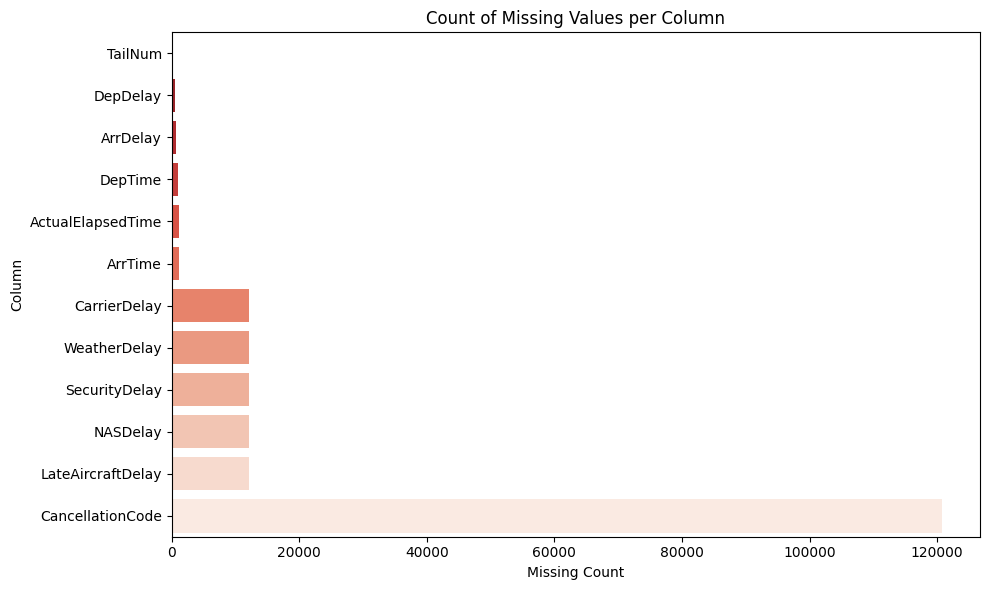

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# ------------------------------------------
# 🔍 Bar Plot of Missing Values by Column
# ------------------------------------------
missing_data = combined_df.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values()

plt.figure(figsize=(10, 6))
sns.barplot(x=missing_data.values, y=missing_data.index, palette="Reds_r")
plt.title("Count of Missing Values per Column")
plt.xlabel("Missing Count")
plt.ylabel("Column")
plt.tight_layout()
plt.show()


In [ ]:
# ------------------------------------------
# 🔢 Count of Unique Values by Column
# ------------------------------------------
print("🎯 Distinct value counts for each column:\n")
unique_counts = combined_df.nunique().sort_values(ascending=False)
print(unique_counts)

🎯 Distinct value counts for each column:

TailNum              8980
FlightNum            7408
ArrTime              2704
Distance             1317
CRSArrTime           1288
DepTime              1284
CRSDepTime           1150
ActualElapsedTime     922
ArrDelay              732
DepDelay              644
CRSElapsedTime        457
Dest                  285
Origin                284
CarrierDelay          251
LateAircraftDelay     248
NASDelay              200
TaxiOut               168
WeatherDelay          168
TaxiIn                140
SecurityDelay          38
DayofMonth             31
UniqueCarrier          23
Month                  12
DayOfWeek               7
Year                    4
CancellationCode        3
Cancelled               2
Diverted                2
Delayed                 2
dtype: int64


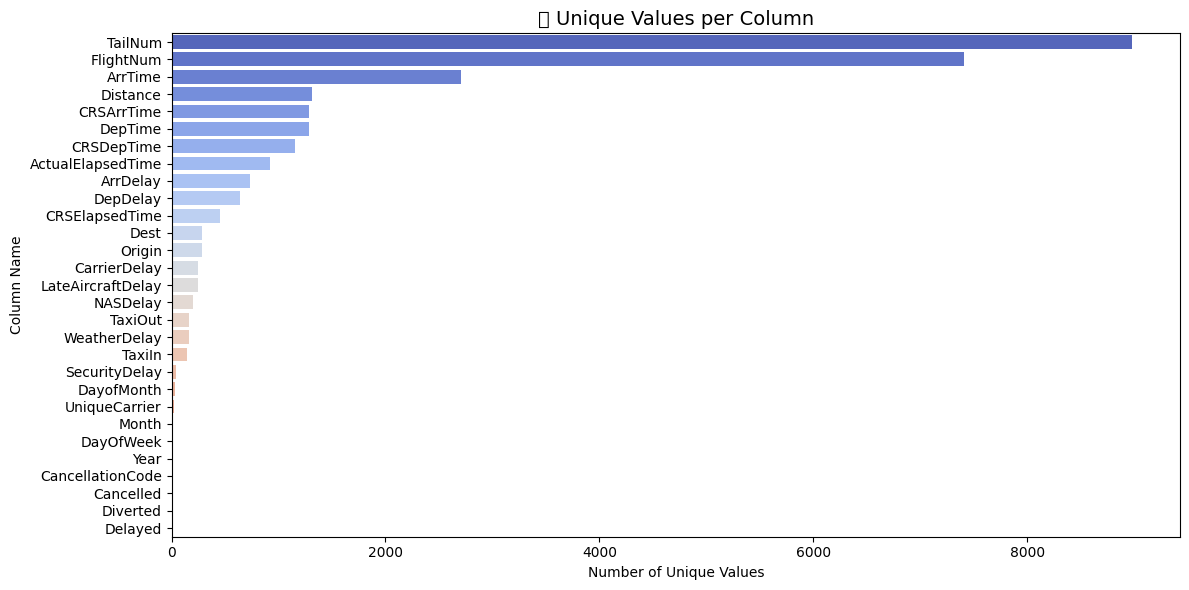

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get number of unique values per column
unique_counts = combined_df.nunique().sort_values(ascending=False)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x=unique_counts.values, y=unique_counts.index, palette="coolwarm")
plt.title("🔢 Unique Values per Column", fontsize=14)
plt.xlabel("Number of Unique Values")
plt.ylabel("Column Name")
plt.tight_layout()
plt.show()


## Target Value Count

In [ ]:
print("Value counts for 'Delayed' column:")
print(combined_df['Delayed'].value_counts())

Value counts for 'Delayed' column:
Delayed
N    61404
Y    60137
Name: count, dtype: int64


## Handling Missing Values

In [ ]:
# ------------------------------------------------
# 🧹 Step 1: Remove Unnecessary Columns
# ------------------------------------------------
columns_to_drop = ['CancellationCode', 'TailNum']
combined_df.drop(columns=columns_to_drop, inplace=True, errors='ignore')

# ------------------------------------------------
# 🚫 Step 2: Replace Missing Delays with Zero
# ------------------------------------------------
delay_features = ['CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay']
combined_df[delay_features] = combined_df[delay_features].fillna(0)

# ------------------------------------------------
# ⏱️ Step 3: Clean and Impute Time-Related Columns
# ------------------------------------------------
numeric_time_fields = ['DepTime', 'CRSDepTime', 'ArrTime', 'ArrDelay', 'DepDelay', 'ActualElapsedTime']
for time_feature in numeric_time_fields:
    combined_df[time_feature] = pd.to_numeric(combined_df[time_feature], errors='coerce')
    combined_df[time_feature].fillna(combined_df[time_feature].mean(), inplace=True)

# ------------------------------------------------
# 🗓️ Step 4: Fill Missing DayOfWeek with Mode
# ------------------------------------------------
combined_df['DayOfWeek'] = pd.to_numeric(combined_df['DayOfWeek'], errors='coerce')
most_common_day = combined_df['DayOfWeek'].mode()[0]
combined_df['DayOfWeek'].fillna(most_common_day, inplace=True)


In [ ]:
# Count of missing values in each column
print("\nMissing values per column:")
print(combined_df.isnull().sum())


Missing values per column:
Year                 0
Month                0
DayofMonth           0
DayOfWeek            0
DepTime              0
CRSDepTime           0
ArrTime              0
CRSArrTime           0
UniqueCarrier        0
FlightNum            0
ActualElapsedTime    0
CRSElapsedTime       0
ArrDelay             0
DepDelay             0
Origin               0
Dest                 0
Distance             0
TaxiIn               0
TaxiOut              0
Cancelled            0
Diverted             0
CarrierDelay         0
WeatherDelay         0
NASDelay             0
SecurityDelay        0
LateAircraftDelay    0
Delayed              0
dtype: int64


## Label Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder

# ------------------------------------------
# 🎯 Step 1: Separate Features and Target
# ------------------------------------------
features = combined_df.drop(columns='Delayed')
target = combined_df['Delayed']

# ------------------------------------------
# 🔡 Step 2: Encode Categorical Columns
# ------------------------------------------
for feature in features.select_dtypes(include='object').columns:
    encoder = LabelEncoder()
    features[feature] = encoder.fit_transform(features[feature].astype(str))

# ------------------------------------------
# 📋 Step 3: Summary Output
# ------------------------------------------
print("✅ Shape after encoding:", features.shape)
print("\n📊 Encoded feature set info:")
features.info()


✅ Shape after encoding: (121541, 26)

📊 Encoded feature set info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121541 entries, 0 to 121540
Data columns (total 26 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Year               121541 non-null  int64  
 1   Month              121541 non-null  int64  
 2   DayofMonth         121541 non-null  int64  
 3   DayOfWeek          121541 non-null  int64  
 4   DepTime            121541 non-null  float64
 5   CRSDepTime         121541 non-null  int64  
 6   ArrTime            121541 non-null  float64
 7   CRSArrTime         121541 non-null  int64  
 8   UniqueCarrier      121541 non-null  int64  
 9   FlightNum          121541 non-null  int64  
 10  ActualElapsedTime  121541 non-null  float64
 11  CRSElapsedTime     121541 non-null  int64  
 12  ArrDelay           121541 non-null  float64
 13  DepDelay           121541 non-null  float64
 14  Origin             121541 non-null

In [ ]:
print("🔍 Object columns before encoding:")
print(combined_df.select_dtypes(include='object').columns.tolist())

print("\n🔄 Data types after encoding:")
print(features.dtypes.value_counts())


🔍 Object columns before encoding:
['UniqueCarrier', 'Origin', 'Dest', 'CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay', 'Delayed']

🔄 Data types after encoding:
int64      21
float64     5
Name: count, dtype: int64


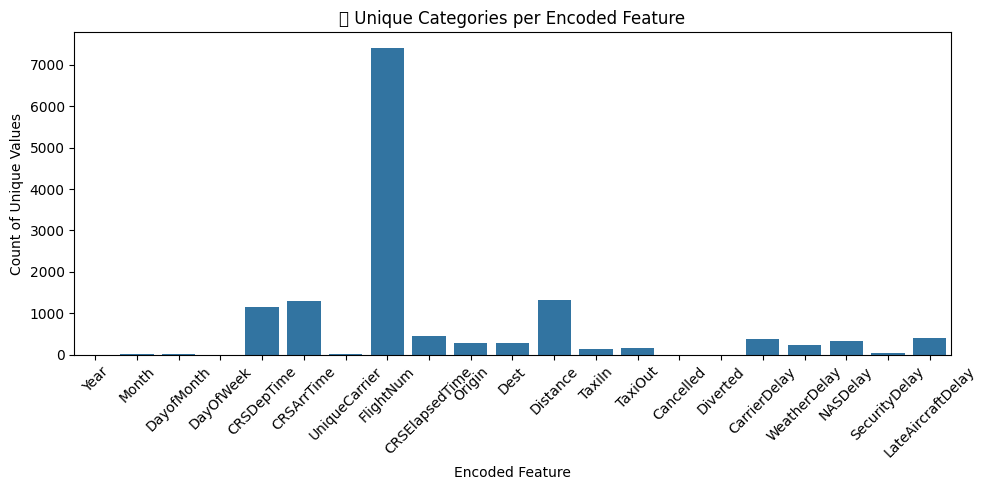

In [ ]:
cat_cols = features.select_dtypes(include='int64').columns
unique_counts = [features[col].nunique() for col in cat_cols]

plt.figure(figsize=(10, 5))
sns.barplot(x=cat_cols, y=unique_counts)
plt.xticks(rotation=45)
plt.title("🔢 Unique Categories per Encoded Feature")
plt.ylabel("Count of Unique Values")
plt.xlabel("Encoded Feature")
plt.tight_layout()
plt.show()


## Coorelation Heatmap

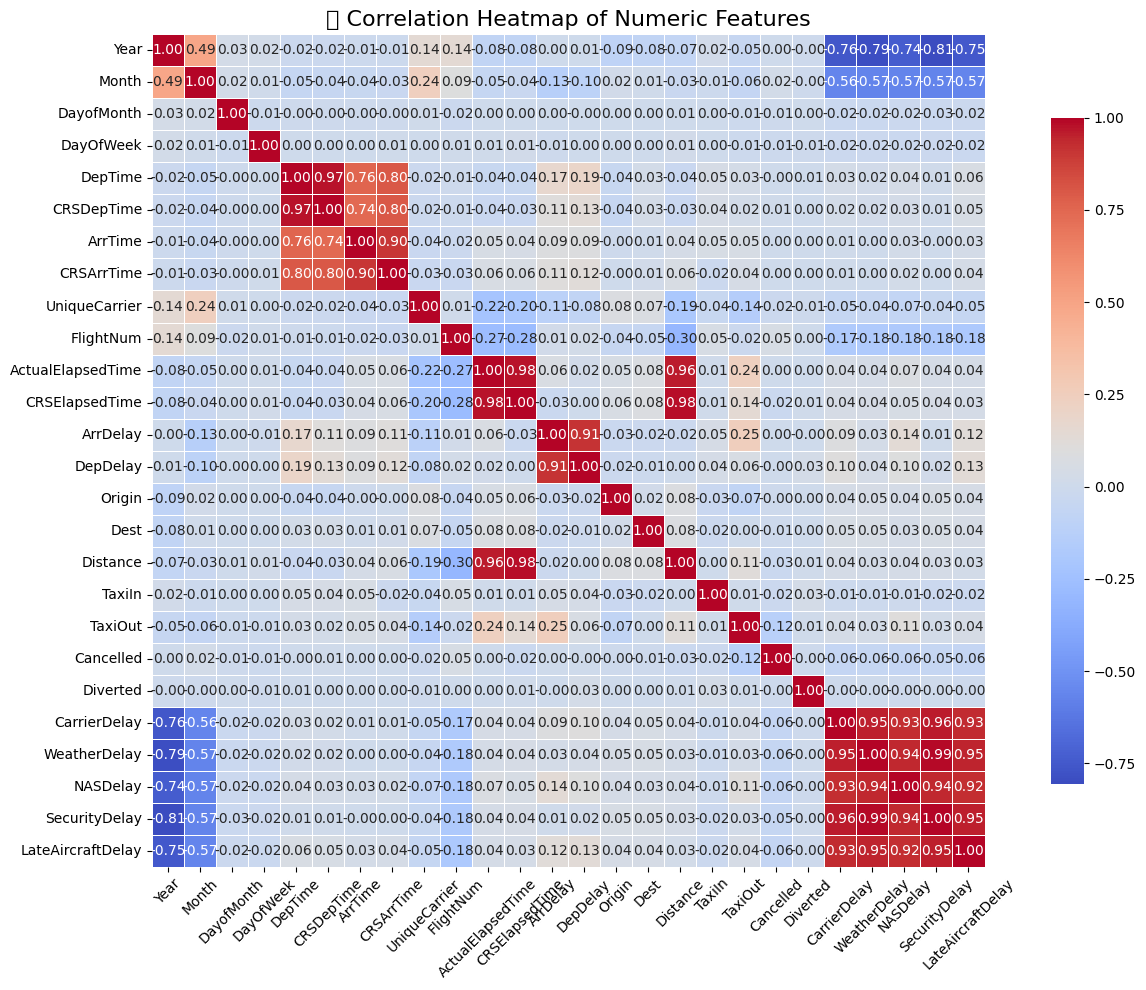

In [ ]:
# --------------------------------------------------
# 📈 Step: Correlation Analysis of Numeric Features
# --------------------------------------------------

# Extract only numeric features
numeric_features = features.select_dtypes(include='number')

# Compute correlation matrix
correlation_matrix = numeric_features.corr()

# Plot the heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True,
    cbar_kws={'shrink': 0.8}
)
plt.title("🔗 Correlation Heatmap of Numeric Features", fontsize=16)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## Monthly Delay Trend

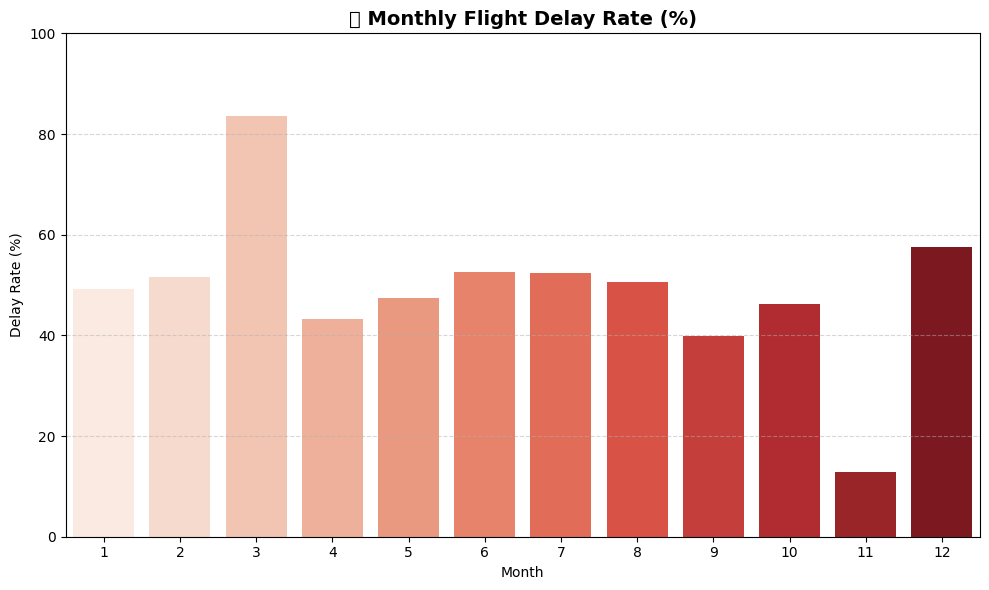

In [65]:
# Step 1: Calculate delay rate per month
monthly_delay_rate = (
    combined_df.groupby(['Month', 'Delayed'])
    .size()
    .reset_index(name='Count')
    .pivot(index='Month', columns='Delayed', values='Count')
    .fillna(0)
)

monthly_delay_rate['DelayRate (%)'] = (
    monthly_delay_rate['Y'] / (monthly_delay_rate['Y'] + monthly_delay_rate['N']) * 100
)

# Step 2: Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    x=monthly_delay_rate.index,
    y=monthly_delay_rate['DelayRate (%)'],
    palette='Reds'
)

plt.title("📅 Monthly Flight Delay Rate (%)", fontsize=14, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Delay Rate (%)")
plt.ylim(0, 100)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# Show top 10 highest correlations (excluding 1.0 self-correlations)
corr_unstacked = correlation_matrix.abs().unstack().sort_values(ascending=False)
high_corr_pairs = corr_unstacked[corr_unstacked < 1].drop_duplicates().head(10)
print("Top 10 strongest correlated pairs:\n", high_corr_pairs)

Top 10 strongest correlated pairs:
 SecurityDelay      WeatherDelay      0.991022
Distance           CRSElapsedTime    0.982179
ActualElapsedTime  CRSElapsedTime    0.976685
DepTime            CRSDepTime        0.973354
ActualElapsedTime  Distance          0.961937
SecurityDelay      CarrierDelay      0.960789
WeatherDelay       CarrierDelay      0.952909
LateAircraftDelay  SecurityDelay     0.950707
                   WeatherDelay      0.947948
SecurityDelay      NASDelay          0.939713
dtype: float64


## Target Distribution

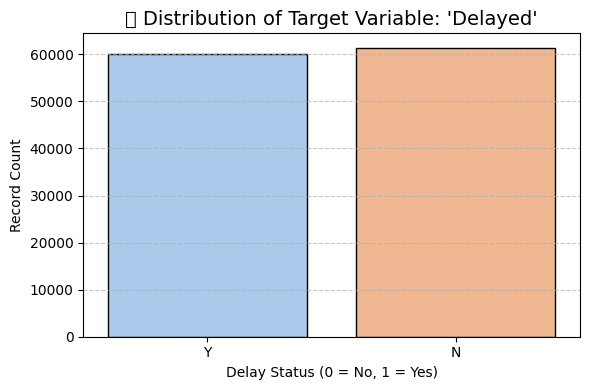

In [ ]:
# --------------------------------------------------
# 🎯 Visualize Distribution of Target Variable
# --------------------------------------------------
plt.figure(figsize=(6, 4))
sns.countplot(x=target, palette='pastel', edgecolor='black')

plt.title("📊 Distribution of Target Variable: 'Delayed'", fontsize=14)
plt.xlabel("Delay Status (0 = No, 1 = Yes)")
plt.ylabel("Record Count")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Dropping Data Leakage features

In [ ]:
from sklearn.preprocessing import LabelEncoder

# ------------------------------------------
# 🎯 Step 1: Encode the Target Column ('Delayed')
# ------------------------------------------
target_encoder = LabelEncoder()
encoded_target = target_encoder.fit_transform(target)  # 'N' → 0, 'Y' → 1

# ------------------------------------------
# 🛑 Step 2: Remove Leakage Columns
# ------------------------------------------
# These columns would not be available at prediction time
leakage_features = [
    'ArrDelay', 'DepDelay', 'CarrierDelay', 'WeatherDelay',
    'NASDelay', 'SecurityDelay', 'LateAircraftDelay',
    'Cancelled', 'Diverted', 'DepTime', 'ArrTime', 'Year'
]

features = features.drop(columns=leakage_features, errors='ignore')

In [ ]:
# ------------------------------------------
# 🧾 Summary: Final Features for Model Training
# ------------------------------------------
print("✅ Final set of features used for prediction:\n")
for col in features.columns:
    print(f"• {col}")

✅ Final set of features used for prediction:

• Month
• DayofMonth
• DayOfWeek
• CRSDepTime
• CRSArrTime
• UniqueCarrier
• FlightNum
• ActualElapsedTime
• CRSElapsedTime
• Origin
• Dest
• Distance
• TaxiIn
• TaxiOut


## Feature Engineering

In [ ]:
# ------------------------------------------------
# ⚙️ Step: Custom Feature Engineering
# ------------------------------------------------

# 1. Extract scheduled departure hour from CRSDepTime
features['DepHour'] = (features['CRSDepTime'] // 100).astype(int)

# 2. Create weekend indicator based on DayOfWeek
features['IsWeekend'] = features['DayOfWeek'].apply(lambda day: 1 if day in [6, 7] else 0)

# 3. Duration ratio: scheduled flight time per mile (avoids divide-by-zero with +1)
features['DurationRatio'] = features['CRSElapsedTime'] / (features['Distance'] + 1)

# 4. Sum of TaxiIn and TaxiOut times
features['TotalTaxiTime'] = features['TaxiIn'] + features['TaxiOut']

# 5. Construct route feature and map its frequency
features['Route'] = features['Origin'].astype(str) + "_" + features['Dest'].astype(str)
features['RouteFreq'] = features['Route'].map(features['Route'].value_counts())

# 6. Drop intermediate 'Route' feature after use
features.drop(columns=['Route'], inplace=True, errors='ignore')

## Test & Train Split and Model Training

In [ ]:
from sklearn.model_selection import train_test_split

# ------------------------------------------------
# 🧪 Split the Data into Training and Testing Sets
# ------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    features, encoded_target,
    test_size=0.2,
    stratify=encoded_target,
    random_state=42
)

print(f"📊 Training samples: {X_train.shape[0]}")
print(f"🧪 Testing samples: {X_test.shape[0]}")


📊 Training samples: 97232
🧪 Testing samples: 24309


In [ ]:
pip install lightgbm

In [ ]:
# ----------------------------------------------------------
# 🚀 Train & Evaluate a LightGBM Classifier
# ----------------------------------------------------------
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Step 1: Initialize the model
model = LGBMClassifier(random_state=42)

# Step 2: Fit on training data
model.fit(X_train, y_train)

# Step 3: Make predictions
y_pred = model.predict(X_test)

# Step 4: Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Model Accuracy: {accuracy:.4f}\n")

print("🧾 Classification Report:")
print(classification_report(y_test, y_pred))

print("📊 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


[LightGBM] [Info] Number of positive: 48109, number of negative: 49123
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006068 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2802
[LightGBM] [Info] Number of data points in the train set: 97232, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.494786 -> initscore=-0.020858
[LightGBM] [Info] Start training from score -0.020858
✅ Model Accuracy: 0.7986

🧾 Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.88      0.82     12281
           1       0.85      0.72      0.78     12028

    accuracy                           0.80     24309
   macro avg       0.81      0.80      0.80     24309
weighted avg       0.81      0.80      0.80     24309

📊 Confusion Matrix:
[[10812  1469]
 [ 3427  8601]]


## Confusion Matrix

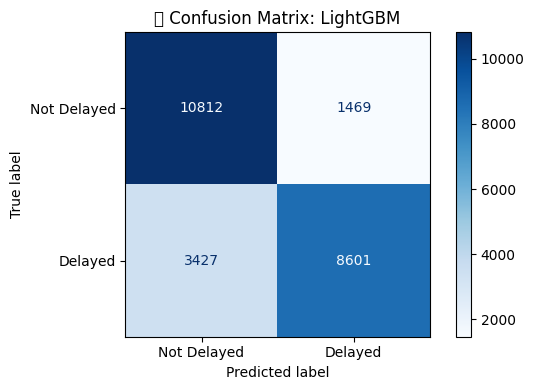

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# -----------------------------------------------
# 📊 Confusion Matrix for LightGBM Predictions
# -----------------------------------------------

# Step 1: Predict on test set
y_pred = model.predict(X_test)  # assuming 'model' is your trained LGBMClassifier

# Step 2: Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])  # 0: Not Delayed, 1: Delayed

# Step 3: Display it with labels
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Delayed', 'Delayed'])

# Step 4: Plot the matrix
fig, ax = plt.subplots(figsize=(6, 4))
disp.plot(cmap='Blues', values_format='d', ax=ax)
plt.title("📉 Confusion Matrix: LightGBM")
plt.grid(False)
plt.tight_layout()
plt.show()

## feature importance

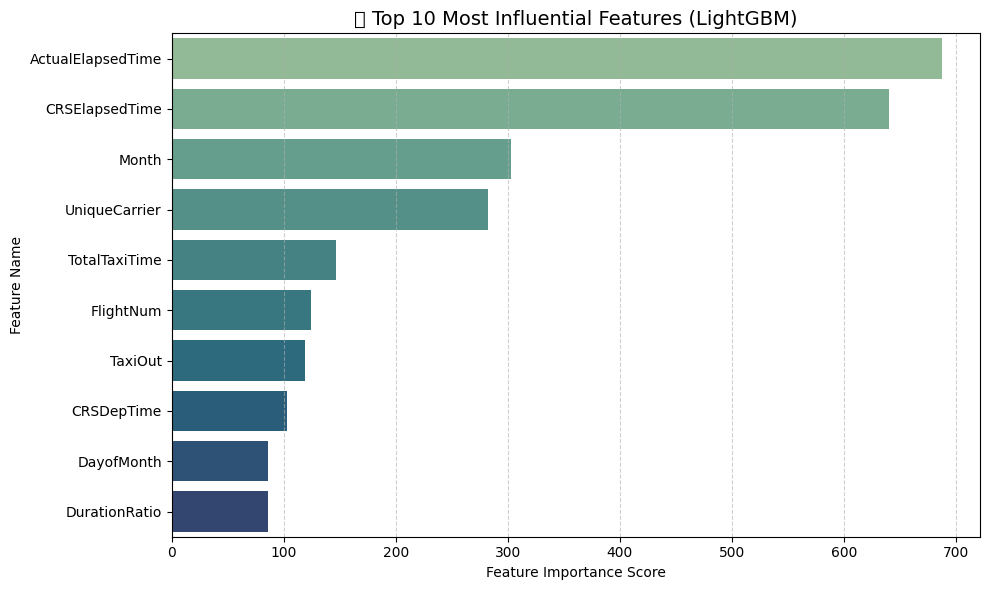

In [ ]:
# -----------------------------------------------------------
# 🔍 Step: Visualize Top 10 Most Important Model Features
# -----------------------------------------------------------

# Step 1: Extract feature importances and their names
importance_scores = model.feature_importances_  # assuming 'model' is the trained LGBMClassifier
feature_labels = features.columns  # match training feature names

# Step 2: Create a sorted DataFrame of importances
top_features = pd.DataFrame({
    'Feature': feature_labels,
    'Importance': importance_scores
}).sort_values(by='Importance', ascending=False).head(10)

# Step 3: Plot the top features
plt.figure(figsize=(10, 6))
sns.barplot(data=top_features, x='Importance', y='Feature', palette='crest')
plt.title("🔝 Top 10 Most Influential Features (LightGBM)", fontsize=14)
plt.xlabel("Feature Importance Score")
plt.ylabel("Feature Name")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## ROC AND AUC CURVE

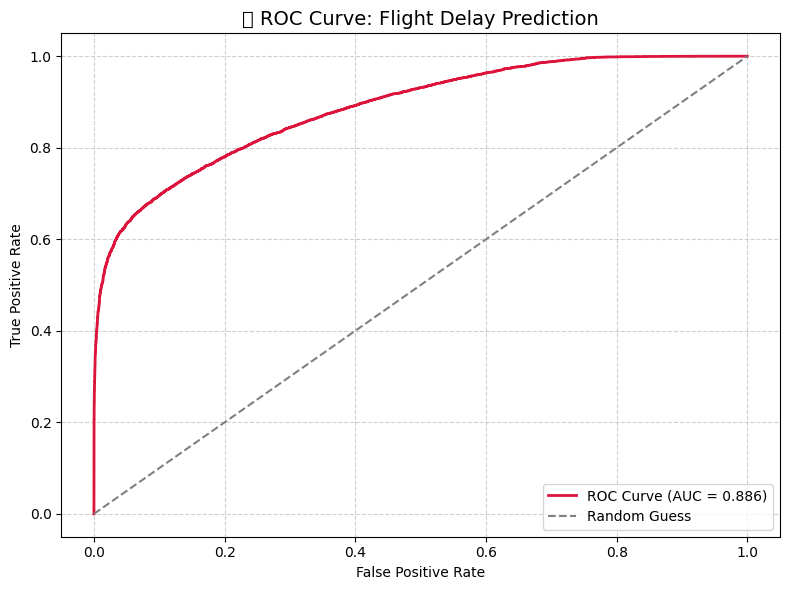

In [ ]:
# -------------------------------------------------------
# 📈 ROC Curve & AUC – Evaluating Binary Classifier
# -------------------------------------------------------

# Step 1: Get predicted probabilities for the positive class (Delayed = 1)
y_probs = model.predict_proba(X_test)[:, 1]

# Step 2: Calculate False Positive Rate, True Positive Rate, and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Step 3: Plot the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='crimson', lw=2, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5, label='Random Guess')

plt.title('📉 ROC Curve: Flight Delay Prediction', fontsize=14)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


## Learning Curve

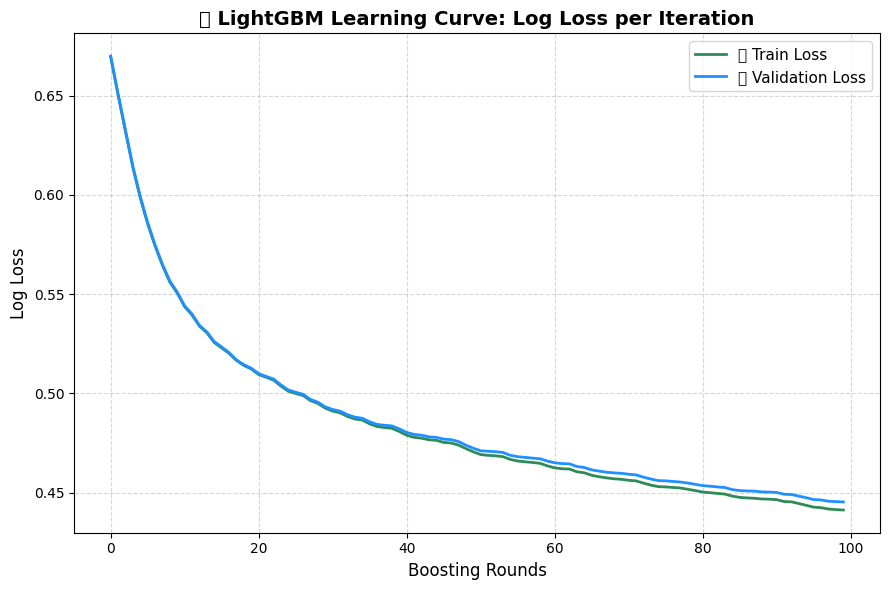

In [ ]:
import lightgbm as lgb
import matplotlib.pyplot as plt

# Step 1: Prepare datasets
train_set = lgb.Dataset(X_train, label=y_train)
valid_set = lgb.Dataset(X_test, label=y_test, reference=train_set)

# Step 2: Define parameters
params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'learning_rate': 0.1,
    'max_depth': 4,
    'verbosity': -1,
    'seed': 42
}

# Step 3: Train and record log loss values
evals_result = {}

model = lgb.train(
    params,
    train_set,
    valid_sets=[train_set, valid_set],
    valid_names=['Train', 'Validation'],
    num_boost_round=100,
    callbacks=[lgb.record_evaluation(evals_result)]
)

# Step 4: Styled learning curve plot
plt.figure(figsize=(9, 6))
plt.plot(evals_result['Train']['binary_logloss'], label='🟢 Train Loss', color='#2E8B57', linewidth=2)
plt.plot(evals_result['Validation']['binary_logloss'], label='🔵 Validation Loss', color='#1E90FF', linewidth=2)

plt.title('📉 LightGBM Learning Curve: Log Loss per Iteration', fontsize=14, fontweight='bold')
plt.xlabel('Boosting Rounds', fontsize=12)
plt.ylabel('Log Loss', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [63]:
# ---------------------------------------------
# 🔮 Delay Prediction on New 10-Record Dataset
# ---------------------------------------------

# Step 1: Load the input Excel file
original_df = pd.read_excel("/content/Target Data Set1.xlsx")
target_df = original_df.copy()

# Step 2: Drop placeholder 'Delayed' column if present
target_df.drop(columns=['Delayed'], errors='ignore', inplace=True)

# Step 3: Convert relevant object columns to numeric
time_columns = ['DepTime', 'CRSDepTime', 'CRSArrTime', 'CRSElapsedTime']
for col in time_columns:
    target_df[col] = pd.to_numeric(target_df[col], errors='coerce')

# Step 4: Feature Engineering (MUST match training logic)
target_df['DepHour'] = (target_df['CRSDepTime'] // 100).astype(int)
target_df['IsWeekend'] = target_df['DayOfWeek'].apply(lambda x: 1 if x in [6, 7] else 0)
target_df['DurationRatio'] = target_df['CRSElapsedTime'] / (target_df['Distance'] + 1)
target_df['TotalTaxiTime'] = target_df['TaxiIn'] + target_df['TaxiOut']
target_df['Route'] = target_df['Origin'].astype(str) + "_" + target_df['Dest'].astype(str)

# Use route frequency map from training data (using final_df)
training_routes = combined_df['Origin'].astype(str) + "_" + combined_df['Dest'].astype(str)
route_freq_map = training_routes.value_counts()
target_df['RouteFreq'] = target_df['Route'].map(route_freq_map)

# Clean up intermediate route column
target_df.drop(columns=['Route'], inplace=True, errors='ignore')

# Step 5: Encode object-type features (same as in training)
for col in target_df.select_dtypes(include='object').columns:
    target_df[col] = LabelEncoder().fit_transform(target_df[col].astype(str))

# Step 6: Drop leakage columns
leakage_cols = [
    'ArrDelay', 'DepDelay', 'CarrierDelay', 'WeatherDelay',
    'NASDelay', 'SecurityDelay', 'LateAircraftDelay',
    'Cancelled', 'Diverted', 'DepTime', 'ArrTime', 'Year'
]

target_df.drop(columns=leakage_cols, errors='ignore', inplace=True)

# Step 7: Use the exact training-time features
trained_features = [
    'Month', 'DayofMonth', 'DayOfWeek', 'CRSDepTime',
    'CRSArrTime', 'UniqueCarrier', 'FlightNum', 'ActualElapsedTime',
    'CRSElapsedTime', 'Origin', 'Dest', 'Distance', 'TaxiIn', 'TaxiOut',
    'DepHour', 'IsWeekend', 'DurationRatio', 'TotalTaxiTime', 'RouteFreq'
]
target_X = target_df[trained_features]

# Step 8: Predict using your trained model (LightGBM, CatBoost, etc.)
# Convert probabilities to class labels
predictions = (model.predict(target_X) >= 0.5).astype(int)

# Step 9: Decode predictions back to 'Y' and 'N'
label_map = LabelEncoder().fit(['N', 'Y'])  # 0 = N, 1 = Y
original_df['Delayed'] = label_map.inverse_transform(predictions)

# Step 10: Save to Excel
original_df.to_excel("Predicted_10_Records.xlsx", index=False)
print("✅ Predictions saved to 'Predicted_10_Records.xlsx'")


✅ Predictions saved to 'Predicted_10_Records.xlsx'
